
## Kiến trúc

1. Data audit, clean, normalize
2. Market feature engineering
3. Temporal alignment / chống future leakage
4. Customer historical preference & investment style
5. **Customer–Stock Graph** từ BUY history + holdings snapshot
6. **LightGCN** để học customer/stock embeddings
7. GraphScore + StyleScore + HistoricalPreference
8. Candidate BUY hard-filter
9. Hybrid với MarketScore
10. Temporal validation/test
11. Precision@K, Recall@K, HitRate@K, NDCG@K, MAP@K, Candidate Coverage
12. Final Top-K recommendation export

## 0. Config

In [ ]:
from pathlib import Path
import gc
import math
import random
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 200)

# ============================================================
# PATHS
# ============================================================
KAGGLE_INPUT_DIR = Path(
    "/kaggle/input/datasets/ngivitgccychui/"
    "personalized-stock-recommendation-dataset"
)

# Local fallback chỉ để notebook vẫn có thể smoke-test ngoài Kaggle.
INPUT_DIR = KAGGLE_INPUT_DIR if KAGGLE_INPUT_DIR.exists() else Path("/mnt/data")

OUTPUT_DIR = Path("/kaggle/working/stock_recommender_graph")
if not Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/mnt/data/stock_recommender_graph")

CLEAN_DIR = OUTPUT_DIR / "cleaned"
FEATURE_DIR = OUTPUT_DIR / "features"
GRAPH_DIR = OUTPUT_DIR / "graph"
EVAL_DIR = OUTPUT_DIR / "evaluation"
REC_DIR = OUTPUT_DIR / "recommendations"

for d in [OUTPUT_DIR, CLEAN_DIR, FEATURE_DIR, GRAPH_DIR, EVAL_DIR, REC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# TEMPORAL SPLIT
# ============================================================
TRAIN_END = pd.Timestamp("2021-12-31")
VALID_START = pd.Timestamp("2022-01-01")
VALID_END = pd.Timestamp("2022-06-30")
TEST_START = pd.Timestamp("2022-07-01")
TEST_END = pd.Timestamp("2022-12-30")

HORIZON_TRADING_DAYS = 5
TOP_K = 5
CANDIDATE_RECOMMENDATIONS = ("BUY",)

RECENCY_HALF_LIFE_DAYS = 90
MIN_BUYS_FOR_PERSONALIZATION = 3

GRAPH_COMPONENT_WEIGHT = 0.50
STYLE_COMPONENT_WEIGHT = 0.30
HISTORY_COMPONENT_WEIGHT = 0.20

assert abs(
    GRAPH_COMPONENT_WEIGHT + STYLE_COMPONENT_WEIGHT + HISTORY_COMPONENT_WEIGHT - 1.0
) < 1e-9

ALPHA_GRID = np.round(np.linspace(0, 1, 11), 2)

GRAPH_EMBED_DIM = 64
GRAPH_NUM_LAYERS = 3
GRAPH_EPOCHS = 150
GRAPH_LR = 0.01
GRAPH_L2 = 1e-4

BUY_EDGE_WEIGHT = 0.80
HOLDING_EDGE_WEIGHT = 0.20

DEBUG_MODE = False

if DEBUG_MODE:
    GRAPH_EPOCHS = 30
    EVAL_DATE_STRIDE = 10
    MAX_VALID_DATES = 8
    MAX_TEST_DATES = 8
else:
    EVAL_DATE_STRIDE = 1
    MAX_VALID_DATES = None
    MAX_TEST_DATES = None

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("INPUT :", INPUT_DIR)
print("OUTPUT:", OUTPUT_DIR)
print("DEVICE:", DEVICE)
print("DEBUG_MODE:", DEBUG_MODE)

INPUT : /kaggle/input/datasets/ngivitgccychui/personalized-stock-recommendation-dataset
OUTPUT: /kaggle/working/stock_recommender_graph
DEVICE: cpu
DEBUG_MODE: False


## 1. Helper functions

In [2]:
def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def clean_str(df, col, upper=False):
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()
        if upper:
            df[col] = df[col].str.upper()
    return df


def numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df


def minmax01(s):
    s = pd.Series(s, index=getattr(s, "index", None), dtype=float)
    lo, hi = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(lo) or pd.isna(hi) or abs(hi - lo) < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - lo) / (hi - lo)


def safe_weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])


def recency_score(days, half_life=RECENCY_HALF_LIFE_DAYS):
    if pd.isna(days):
        return 0.0
    return float(np.exp(-np.log(2) * max(float(days), 0.0) / half_life))


def ndcg_at_k(recommended, relevant, k):
    rel = set(relevant)
    rec = list(recommended)[:k]
    if len(rel) == 0:
        return np.nan
    dcg = sum((1.0 / np.log2(i + 2)) for i, item in enumerate(rec) if item in rel)
    ideal_hits = min(len(rel), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def average_precision_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return np.nan
    hits = 0
    score = 0.0
    for i, item in enumerate(list(recommended)[:k], start=1):
        if item in rel:
            hits += 1
            score += hits / i
    return score / min(len(rel), k)


def ranking_metrics(recommended, relevant, k=TOP_K):
    rec = list(recommended)[:k]
    rel = set(relevant)
    hits = sum(item in rel for item in rec)
    return {
        f"precision@{k}": hits / k,
        f"recall@{k}": hits / len(rel) if rel else np.nan,
        f"hitrate@{k}": float(hits > 0),
        f"ndcg@{k}": ndcg_at_k(rec, rel, k),
        f"map@{k}": average_precision_at_k(rec, rel, k),
    }


def safe_save_table(df, path_stem):
    path_stem = Path(path_stem)
    try:
        out = path_stem.with_suffix(".parquet")
        df.to_parquet(out, index=False)
        return out
    except Exception:
        out = path_stem.with_suffix(".pkl")
        df.to_pickle(out)
        print(f"Parquet unavailable -> saved Pickle: {out.name}")
        return out

## 2. Load raw data

In [3]:
files = {
    "candidate": "candidate_stocks_research.csv",
    "holdings": "customer_holdings.csv",
    "profile": "customer_profile.csv",
    "transactions": "customer_transactions_raw.csv",
    "market_index": "market_index_daily.csv",
    "securities": "securities_master.csv",
    "stock_market": "stock_market_daily.csv",
}

missing_files = [v for v in files.values() if not (INPUT_DIR / v).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing input files: {missing_files}")

raw = {k: normalize_columns(pd.read_csv(INPUT_DIR / v)) for k, v in files.items()}

for name, df in raw.items():
    print(f"{name:15s} {len(df):>10,} rows x {df.shape[1]} cols")

candidate           60,000 rows x 7 cols
holdings           428,876 rows x 6 cols
profile              2,000 rows x 7 cols
transactions       489,681 rows x 9 cols
market_index         4,004 rows x 7 cols
securities           1,523 rows x 8 cols
stock_market       861,693 rows x 7 cols


## 3. STEP 1 — Clean & normalize

In [4]:
# ---------------- SECURITIES ----------------
securities = raw["securities"].copy()
for c in ["stock_code", "exchange", "instrument_type"]:
    securities = clean_str(securities, c, upper=True)
if "instrument_type" in securities.columns:
    securities = securities[securities["instrument_type"] == "STOCK"].copy()
securities = securities.dropna(subset=["stock_code"]).drop_duplicates("stock_code", keep="last")
if "company_short_name" in securities.columns and securities["company_short_name"].isna().all():
    securities = securities.drop(columns=["company_short_name"])

# ---------------- PROFILE ----------------
profile = raw["profile"].copy()
profile = clean_str(profile, "customer_id", upper=True)
for c in ["customer_type", "risk_level", "investment_horizon"]:
    profile = clean_str(profile, c, upper=True)
profile = dates(profile, ["account_open_date"])
profile = numeric(profile, ["portfolio_value", "cash_balance"])
profile = profile.dropna(subset=["customer_id"]).drop_duplicates("customer_id", keep="last")

# Không dùng portfolio_value/cash_balance cho historical backtest vì có thể là snapshot cuối kỳ.
customer_profile_static = profile.drop(
    columns=[c for c in ["portfolio_value", "cash_balance"] if c in profile.columns],
    errors="ignore"
)

# ---------------- TRANSACTIONS ----------------
transactions = raw["transactions"].copy()
for c in ["customer_id", "stock_code", "exchange", "side"]:
    transactions = clean_str(transactions, c, upper=True)
transactions = dates(transactions, ["trade_date"])
transactions = numeric(transactions, ["quantity", "price"])
transactions = transactions.dropna(
    subset=["customer_id", "stock_code", "trade_date", "quantity", "price"]
)
transactions = transactions[(transactions["quantity"] > 0) & (transactions["price"] > 0)].copy()
transactions["transaction_value"] = transactions["quantity"] * transactions["price"]
transactions = transactions.sort_values(["trade_date", "customer_id", "stock_code"]).reset_index(drop=True)

# ---------------- HOLDINGS ----------------
holdings = raw["holdings"].copy()
for c in ["customer_id", "stock_code"]:
    holdings = clean_str(holdings, c, upper=True)
holdings = dates(holdings, ["snapshot_date"])
holdings = numeric(holdings, ["quantity", "avg_cost", "average_cost", "market_value"])
holdings = holdings.dropna(subset=["customer_id", "stock_code", "snapshot_date"])
if "quantity" in holdings.columns:
    holdings = holdings[holdings["quantity"] >= 0].copy()
holdings = holdings.drop_duplicates(
    ["snapshot_date", "customer_id", "stock_code"], keep="last"
)
holdings = holdings.sort_values(["snapshot_date", "customer_id", "stock_code"]).reset_index(drop=True)

# ---------------- CANDIDATE ----------------
candidate = raw["candidate"].copy()
candidate = clean_str(candidate, "stock_code", upper=True)
candidate = clean_str(candidate, "recommendation", upper=True)
candidate = dates(candidate, ["research_date"])
candidate = numeric(candidate, ["market_score", "candidate_rank", "buy_price", "sell_price"])
candidate = candidate.dropna(subset=["research_date", "stock_code"])
candidate = candidate.drop_duplicates(["research_date", "stock_code"], keep="last")
candidate = candidate.sort_values(["research_date", "candidate_rank"]).reset_index(drop=True)

# ---------------- STOCK MARKET ----------------
stock_market = raw["stock_market"].copy()
stock_market = clean_str(stock_market, "stock_code", upper=True)
stock_market = dates(stock_market, ["date"])
stock_market = numeric(stock_market, ["open", "high", "low", "close", "volume"])
stock_market = stock_market.dropna(subset=["date", "stock_code"])

# vnstock price: nghìn VND -> VND, đồng nhất với transaction price.
for c in ["open", "high", "low", "close"]:
    stock_market[c] = stock_market[c] * 1000.0

stock_market["invalid_price_flag"] = (
    stock_market[["open", "high", "low", "close"]] <= 0
).any(axis=1)
stock_market["ohlc_anomaly_flag"] = (
    (stock_market["high"] < stock_market["low"]) |
    (stock_market["high"] < stock_market[["open", "close"]].max(axis=1)) |
    (stock_market["low"] > stock_market[["open", "close"]].min(axis=1))
)
stock_market = stock_market.drop_duplicates(["date", "stock_code"], keep="last")
stock_market = stock_market.sort_values(["stock_code", "date"]).reset_index(drop=True)

# ---------------- MARKET INDEX ----------------
market_index = raw["market_index"].copy()
market_index = clean_str(market_index, "index_code", upper=True)
market_index = dates(market_index, ["date"])
market_index = numeric(market_index, ["open", "high", "low", "close", "volume"])
market_index = market_index.dropna(subset=["date", "index_code"])
market_index["invalid_price_flag"] = (
    market_index[["open", "high", "low", "close"]] <= 0
).any(axis=1)
market_index["ohlc_anomaly_flag"] = (
    (market_index["high"] < market_index["low"]) |
    (market_index["high"] < market_index[["open", "close"]].max(axis=1)) |
    (market_index["low"] > market_index[["open", "close"]].min(axis=1))
)
market_index = market_index.drop_duplicates(["date", "index_code"], keep="last")
market_index = market_index.sort_values(["index_code", "date"]).reset_index(drop=True)

print("Clean complete")
print("transactions:", transactions.shape)
print("holdings    :", holdings.shape)
print("candidate   :", candidate.shape)
print("securities  :", securities.shape)
print("stock_market:", stock_market.shape)
print("market_index:", market_index.shape)

del raw
gc.collect()

Clean complete
transactions: (489681, 10)
holdings    : (428876, 6)
candidate   : (60000, 7)
securities  : (1523, 7)
stock_market: (861693, 9)
market_index: (4004, 9)


200

## 4. Data integrity checks

In [5]:
market_stocks = set(stock_market.stock_code)
master_stocks = set(securities.stock_code)

checks = {
    "candidate_not_market": sorted(set(candidate.stock_code) - market_stocks),
    "transactions_not_market": sorted(set(transactions.stock_code) - market_stocks),
    "holdings_not_market": sorted(set(holdings.stock_code) - market_stocks),
    "candidate_not_master": sorted(set(candidate.stock_code) - master_stocks),
}

for k, v in checks.items():
    print(k, len(v), v[:20])

print("Duplicate transaction_id:", transactions["transaction_id"].duplicated().sum() if "transaction_id" in transactions else "N/A")
print("Stock invalid price rows:", int(stock_market.invalid_price_flag.sum()))
print("Stock OHLC anomaly rows:", int(stock_market.ohlc_anomaly_flag.sum()))
print("Index invalid price rows:", int(market_index.invalid_price_flag.sum()))
print("Index OHLC anomaly rows:", int(market_index.ohlc_anomaly_flag.sum()))

if "account_open_date" in profile.columns:
    chk = transactions.merge(profile[["customer_id", "account_open_date"]], on="customer_id", how="left")
    print("Transactions before account open:", int((chk.trade_date < chk.account_open_date).sum()))

candidate_not_market 0 []
transactions_not_market 0 []
holdings_not_market 0 []
candidate_not_master 0 []
Duplicate transaction_id: 0
Stock invalid price rows: 16
Stock OHLC anomaly rows: 2714
Index invalid price rows: 0
Index OHLC anomaly rows: 8
Transactions before account open: 0


## 5. Save cleaned data

In [6]:
profile.to_csv(CLEAN_DIR / "customer_profile_clean.csv", index=False)
customer_profile_static.to_csv(CLEAN_DIR / "customer_profile_static.csv", index=False)
securities.to_csv(CLEAN_DIR / "securities_master_clean.csv", index=False)

safe_save_table(transactions, CLEAN_DIR / "customer_transactions_clean")
safe_save_table(holdings, CLEAN_DIR / "customer_holdings_clean")
safe_save_table(candidate, CLEAN_DIR / "candidate_stocks_research_clean")
safe_save_table(stock_market, CLEAN_DIR / "stock_market_daily_clean")
safe_save_table(market_index, CLEAN_DIR / "market_index_daily_clean")

print("Saved cleaned data ->", CLEAN_DIR)

Saved cleaned data -> /kaggle/working/stock_recommender_graph/cleaned


## 6. STEP 2 — Stock market features

In [7]:
stock_features = stock_market.copy().sort_values(["stock_code", "date"]).reset_index(drop=True)
stock_features.loc[stock_features["close"] <= 0, "close"] = np.nan
stock_features.loc[stock_features["volume"] < 0, "volume"] = np.nan

g = stock_features.groupby("stock_code", group_keys=False)
for n in [1, 5, 20, 60]:
    stock_features[f"return_{n}d"] = g["close"].pct_change(periods=n, fill_method=None)

stock_features["momentum_20d"] = stock_features["return_20d"]
stock_features["momentum_60d"] = stock_features["return_60d"]

for n in [5, 20, 60]:
    stock_features[f"volatility_{n}d"] = (
        stock_features.groupby("stock_code")["return_1d"]
        .rolling(n, min_periods=n).std()
        .reset_index(level=0, drop=True)
    )

for n in [5, 20]:
    stock_features[f"avg_volume_{n}d"] = (
        stock_features.groupby("stock_code")["volume"]
        .rolling(n, min_periods=n).mean()
        .reset_index(level=0, drop=True)
    )

stock_features["volume_ratio_20d"] = stock_features["volume"] / stock_features["avg_volume_20d"]

for n in [20, 60]:
    stock_features[f"ma_{n}d"] = (
        stock_features.groupby("stock_code")["close"]
        .rolling(n, min_periods=n).mean()
        .reset_index(level=0, drop=True)
    )
    stock_features[f"price_vs_ma{n}"] = stock_features["close"] / stock_features[f"ma_{n}d"] - 1

stock_features["trading_value_est"] = stock_features["close"] * stock_features["volume"]
stock_features["log_trading_value_est"] = np.log1p(stock_features["trading_value_est"].clip(lower=0))

print(stock_features.shape)
display(stock_features.head())

(861693, 27)


,date,stock_code,open,high,low,close,volume,invalid_price_flag,ohlc_anomaly_flag,return_1d,return_5d,return_20d,return_60d,momentum_20d,momentum_60d,volatility_5d,volatility_20d,volatility_60d,avg_volume_5d,avg_volume_20d,volume_ratio_20d,ma_20d,price_vs_ma20,ma_60d,price_vs_ma60,trading_value_est,log_trading_value_est
0,2019-01-02,A32,16700.0,16700.0,16700.0,16700.0,100.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1670000.0,14.328335
1,2019-01-07,A32,16700.0,16700.0,16700.0,16700.0,100.0,False,False,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1670000.0,14.328335
2,2019-02-13,A32,14780.0,14780.0,14780.0,14780.0,100.0,False,False,-0.114970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1478000.0,14.206201
3,2019-02-14,A32,13690.0,13690.0,13690.0,13690.0,100.0,False,False,-0.073748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1369000.0,14.129592
4,2019-02-19,A32,12040.0,12040.0,12040.0,12040.0,100.0,False,False,-0.120526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,1204000.0,14.001161


## 7. Market-index features + relative performance

In [8]:
index_features = market_index.copy().sort_values(["index_code", "date"]).reset_index(drop=True)
index_features.loc[index_features["close"] <= 0, "close"] = np.nan

g_idx = index_features.groupby("index_code", group_keys=False)
for n in [1, 5, 20, 60]:
    index_features[f"market_return_{n}d"] = g_idx["close"].pct_change(periods=n, fill_method=None)

index_features["market_volatility_20d"] = (
    index_features.groupby("index_code")["market_return_1d"]
    .rolling(20, min_periods=20).std()
    .reset_index(level=0, drop=True)
)
index_features["market_avg_volume_20d"] = (
    index_features.groupby("index_code")["volume"]
    .rolling(20, min_periods=20).mean()
    .reset_index(level=0, drop=True)
)
index_features["market_volume_ratio_20d"] = (
    index_features["volume"] / index_features["market_avg_volume_20d"]
)

BENCHMARK_MAP = {"HOSE": "VNINDEX", "HNX": "HNXINDEX", "UPCOM": "UPCOMINDEX"}
master_cols = [c for c in ["stock_code", "exchange", "icb_code", "icb_name"] if c in securities.columns]
market_features = stock_features.merge(securities[master_cols], on="stock_code", how="left")
market_features["benchmark_index"] = market_features["exchange"].map(BENCHMARK_MAP)

idx_cols = [
    "date", "index_code", "market_return_1d", "market_return_5d",
    "market_return_20d", "market_return_60d",
    "market_volatility_20d", "market_volume_ratio_20d"
]
bench = index_features[idx_cols].rename(columns={"index_code": "benchmark_index"})
market_features = market_features.merge(bench, on=["date", "benchmark_index"], how="left")

for n in [1, 5, 20, 60]:
    market_features[f"excess_return_{n}d"] = (
        market_features[f"return_{n}d"] - market_features[f"market_return_{n}d"]
    )

market_features["volatility_vs_market"] = (
    market_features["volatility_20d"] / market_features["market_volatility_20d"]
)
market_features["return_outlier_flag"] = market_features["return_1d"].abs() > 0.20
market_features = market_features.replace([np.inf, -np.inf], np.nan)

MARKET_FEATURE_COLS = [
    "return_1d", "return_5d", "return_20d", "return_60d",
    "volatility_5d", "volatility_20d", "volatility_60d",
    "avg_volume_5d", "avg_volume_20d", "volume_ratio_20d",
    "log_trading_value_est", "price_vs_ma20", "price_vs_ma60",
    "market_return_1d", "market_return_5d", "market_return_20d", "market_return_60d",
    "market_volatility_20d", "excess_return_1d", "excess_return_5d",
    "excess_return_20d", "excess_return_60d", "volatility_vs_market"
]

safe_save_table(market_features, FEATURE_DIR / "market_features_daily")
safe_save_table(index_features, FEATURE_DIR / "index_features_daily")
print("Saved market features")

Saved market features


## 8. Precompute prior-market state for BUY events (strictly before transaction date)

In [9]:
buy_events = transactions[transactions["side"] == "BUY"].copy()
buy_events = buy_events.merge(
    securities[[c for c in ["stock_code", "exchange", "icb_name"] if c in securities.columns]],
    on="stock_code", how="left", suffixes=("", "_master")
)

ASOF_FEATURES = [
    "return_20d", "return_60d", "volatility_20d", "avg_volume_20d",
    "log_trading_value_est", "price_vs_ma20", "excess_return_20d",
    "volatility_vs_market"
]

left = buy_events.sort_values(["trade_date", "stock_code"]).copy()
right = (
    market_features[["date", "stock_code"] + ASOF_FEATURES]
    .rename(columns={"date": "feature_date"})
    .sort_values(["feature_date", "stock_code"])
)
left["stock_code"] = left["stock_code"].astype(str)
right["stock_code"] = right["stock_code"].astype(str)

buy_events_mkt = pd.merge_asof(
    left,
    right,
    left_on="trade_date",
    right_on="feature_date",
    by="stock_code",
    direction="backward",
    allow_exact_matches=False,
)
buy_events_mkt = buy_events_mkt.sort_values(["trade_date", "customer_id"]).reset_index(drop=True)

safe_save_table(buy_events_mkt, FEATURE_DIR / "buy_events_with_prior_market")
print("BUY events:", len(buy_events_mkt))
print("Prior-market volatility coverage:", round(1 - buy_events_mkt["volatility_20d"].isna().mean(), 4))

BUY events: 225570
Prior-market volatility coverage: 0.9851


## 9. Style scales learned from TRAIN period only

In [10]:
train_market = market_features[market_features["date"] <= TRAIN_END].copy()

STYLE_FEATURES = {
    "volatility_20d": "preferred_volatility",
    "return_20d": "preferred_momentum",
    "log_trading_value_est": "preferred_liquidity",
    "excess_return_20d": "preferred_excess_return",
    "price_vs_ma20": "preferred_price_vs_ma20",
}

STYLE_SCALE = {}
for f in STYLE_FEATURES:
    x = pd.to_numeric(train_market[f], errors="coerce")
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    scale = q3 - q1
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = x.std()
    STYLE_SCALE[f] = float(scale if np.isfinite(scale) and scale > 0 else 1.0)

STYLE_SCALE

{'volatility_20d': 0.029623569134025956,
 'return_20d': 0.1495731497833661,
 'log_trading_value_est': 5.039680968475068,
 'excess_return_20d': 0.14463647909876437,
 'price_vs_ma20': 0.07663184153822589}

## 10. Build Customer–Stock Graph interactions

Graph edge signal gồm:

- `BUY preference`: ValueShare + FrequencyShare + Recency
- `Holding share`: tỷ trọng danh mục ở holdings snapshot gần nhất trước cutoff

\[
InteractionStrength = 0.8 BuyPreference + 0.2 HoldingShare
\]

In [11]:
def build_graph_interactions(cutoff_date):
    cutoff_date = pd.Timestamp(cutoff_date)

    # ========================================================
    # BUY preference strictly before cutoff
    # ========================================================
    tx = transactions[
        (transactions["side"] == "BUY") &
        (transactions["trade_date"] < cutoff_date)
    ].copy()

    if tx.empty:
        raise ValueError(f"No BUY transactions before {cutoff_date}")

    buy = (
        tx.groupby(["customer_id", "stock_code"], as_index=False)
        .agg(
            buy_count=("stock_code", "size"),
            buy_value=("transaction_value", "sum"),
            last_buy_date=("trade_date", "max"),
        )
    )

    buy["value_share"] = buy["buy_value"] / buy.groupby("customer_id")["buy_value"].transform("sum")
    buy["frequency_share"] = buy["buy_count"] / buy.groupby("customer_id")["buy_count"].transform("sum")
    buy["days_since_last_buy"] = (cutoff_date - buy["last_buy_date"]).dt.days.clip(lower=0)
    buy["recency"] = np.exp(
        -np.log(2) * buy["days_since_last_buy"] / RECENCY_HALF_LIFE_DAYS
    )
    buy["buy_preference"] = (
        0.40 * buy["value_share"] +
        0.30 * buy["frequency_share"] +
        0.30 * buy["recency"]
    )

    buy_signal = buy[["customer_id", "stock_code", "buy_preference"]].copy()

    # ========================================================
    # Latest holdings snapshot strictly before cutoff
    # ========================================================
    h = holdings[holdings["snapshot_date"] < cutoff_date].copy()

    if not h.empty:
        latest_date = h.groupby("customer_id")["snapshot_date"].transform("max")
        h = h[h["snapshot_date"] == latest_date].copy()

        if "market_value" in h.columns:
            mv = pd.to_numeric(h["market_value"], errors="coerce").fillna(0.0).clip(lower=0)
        else:
            mv = pd.Series(0.0, index=h.index)

        qty = pd.to_numeric(h.get("quantity", 0), errors="coerce").fillna(0.0).clip(lower=0)
        h["_hold_weight"] = np.where(mv > 0, mv, qty)

        hold = h.groupby(["customer_id", "stock_code"], as_index=False)["_hold_weight"].sum()
        denom = hold.groupby("customer_id")["_hold_weight"].transform("sum")
        hold["holding_share"] = np.where(denom > 0, hold["_hold_weight"] / denom, 0.0)
        hold_signal = hold[["customer_id", "stock_code", "holding_share"]]
    else:
        hold_signal = pd.DataFrame(columns=["customer_id", "stock_code", "holding_share"])

    # ========================================================
    # Merge BUY + HOLD signal
    # ========================================================
    edges = buy_signal.merge(
        hold_signal,
        on=["customer_id", "stock_code"],
        how="outer"
    )
    edges["buy_preference"] = edges["buy_preference"].fillna(0.0)
    edges["holding_share"] = edges["holding_share"].fillna(0.0)

    edges["interaction_strength"] = (
        BUY_EDGE_WEIGHT * edges["buy_preference"] +
        HOLDING_EDGE_WEIGHT * edges["holding_share"]
    )

    edges = edges.replace([np.inf, -np.inf], np.nan)
    edges = edges.dropna(subset=["customer_id", "stock_code", "interaction_strength"])
    edges = edges[edges["interaction_strength"] > 0].copy()

    return edges.reset_index(drop=True)


train_graph_edges = build_graph_interactions(VALID_START)
print("TRAIN graph edges:", len(train_graph_edges))
print("Graph customers:", train_graph_edges.customer_id.nunique())
print("Graph stocks:", train_graph_edges.stock_code.nunique())
display(train_graph_edges.head())

TRAIN graph edges: 84477
Graph customers: 1676
Graph stocks: 865


,customer_id,stock_code,buy_preference,holding_share,interaction_strength
0,CUS000001,AAA,0.023680,0.0,0.018944
1,CUS000001,APG,0.175548,0.0,0.140439
2,CUS000001,APS,0.018913,0.0,0.015131
3,CUS000001,BFC,0.053890,0.0,0.043112
4,CUS000001,DCM,0.025168,0.0,0.020134


## 11. LightGCN implementation

In [12]:
def build_lightgcn_graph(interactions):
    user_codes = sorted(interactions["customer_id"].astype(str).unique().tolist())
    item_codes = sorted(interactions["stock_code"].astype(str).unique().tolist())

    user_to_idx = {u: i for i, u in enumerate(user_codes)}
    item_to_idx = {s: i for i, s in enumerate(item_codes)}

    n_users = len(user_codes)
    n_items = len(item_codes)
    num_nodes = n_users + n_items

    graph_df = interactions.copy()
    graph_df["user_idx"] = graph_df["customer_id"].map(user_to_idx).astype(int)
    graph_df["item_idx"] = graph_df["stock_code"].map(item_to_idx).astype(int)

    strength = graph_df["interaction_strength"].to_numpy(dtype=np.float32)
    lo, hi = np.nanmin(strength), np.nanmax(strength)
    if np.isfinite(lo) and np.isfinite(hi) and hi - lo > 1e-12:
        strength_norm = (strength - lo) / (hi - lo)
    else:
        strength_norm = np.ones_like(strength)

    # Không để positive edge quá yếu.
    edge_strength = (0.25 + 0.75 * strength_norm).astype(np.float32)
    graph_df["edge_strength"] = edge_strength

    user_nodes = graph_df["user_idx"].to_numpy(dtype=np.int64)
    item_nodes = graph_df["item_idx"].to_numpy(dtype=np.int64) + n_users

    # Undirected bipartite adjacency.
    src = np.concatenate([user_nodes, item_nodes])
    dst = np.concatenate([item_nodes, user_nodes])
    weights = np.concatenate([edge_strength, edge_strength]).astype(np.float32)

    degree = np.zeros(num_nodes, dtype=np.float32)
    np.add.at(degree, src, weights)
    degree = np.maximum(degree, 1e-12)

    normalized_weights = weights / np.sqrt(degree[src] * degree[dst])

    indices = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
    values = torch.tensor(normalized_weights, dtype=torch.float32)
    adjacency = torch.sparse_coo_tensor(
        indices, values, size=(num_nodes, num_nodes)
    ).coalesce()

    user_positive_items = {
        int(u): set(g["item_idx"].astype(int).tolist())
        for u, g in graph_df.groupby("user_idx")
    }

    return {
        "graph_df": graph_df,
        "n_users": n_users,
        "n_items": n_items,
        "num_nodes": num_nodes,
        "user_codes": user_codes,
        "item_codes": item_codes,
        "user_to_idx": user_to_idx,
        "item_to_idx": item_to_idx,
        "adjacency": adjacency,
        "user_positive_items": user_positive_items,
    }


class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        nn.init.normal_(self.embedding.weight, std=0.1)

    def propagate(self, adjacency):
        x = self.embedding.weight
        embeddings = [x]
        for _ in range(self.num_layers):
            x = torch.sparse.mm(adjacency, x)
            embeddings.append(x)
        return torch.stack(embeddings, dim=0).mean(dim=0)


def sample_negative_items(user_indices, n_items, user_positive_items, rng):
    negatives = np.empty(len(user_indices), dtype=np.int64)
    for k, user_idx in enumerate(user_indices):
        positive_set = user_positive_items[int(user_idx)]
        if len(positive_set) >= n_items:
            negatives[k] = int(rng.integers(0, n_items))
            continue
        while True:
            neg = int(rng.integers(0, n_items))
            if neg not in positive_set:
                negatives[k] = neg
                break
    return negatives


def train_lightgcn(interactions, epochs=GRAPH_EPOCHS, verbose=True):
    graph = build_lightgcn_graph(interactions)
    adjacency = graph["adjacency"].to(DEVICE)

    model = LightGCN(
        graph["num_nodes"],
        embedding_dim=GRAPH_EMBED_DIM,
        num_layers=GRAPH_NUM_LAYERS,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=GRAPH_LR)

    train_df = graph["graph_df"]
    user_idx_np = train_df["user_idx"].to_numpy(dtype=np.int64)
    pos_item_idx_np = train_df["item_idx"].to_numpy(dtype=np.int64)
    edge_weights_np = train_df["edge_strength"].to_numpy(dtype=np.float32)

    n_users = graph["n_users"]
    n_items = graph["n_items"]

    user_idx = torch.tensor(user_idx_np, dtype=torch.long, device=DEVICE)
    pos_item_idx = torch.tensor(pos_item_idx_np + n_users, dtype=torch.long, device=DEVICE)
    edge_weights = torch.tensor(edge_weights_np, dtype=torch.float32, device=DEVICE)

    rng = np.random.default_rng(RANDOM_STATE)
    losses = []

    for epoch in range(1, epochs + 1):
        model.train()

        neg_item_idx_np = sample_negative_items(
            user_idx_np,
            n_items,
            graph["user_positive_items"],
            rng,
        )
        neg_item_idx = torch.tensor(
            neg_item_idx_np + n_users, dtype=torch.long, device=DEVICE
        )

        final_embedding = model.propagate(adjacency)
        user_emb = final_embedding[user_idx]
        pos_emb = final_embedding[pos_item_idx]
        neg_emb = final_embedding[neg_item_idx]

        pos_score = (user_emb * pos_emb).sum(dim=1)
        neg_score = (user_emb * neg_emb).sum(dim=1)

        bpr = F.softplus(neg_score - pos_score)
        weighted_bpr = (bpr * edge_weights).mean()

        e0 = model.embedding.weight
        reg = (
            e0[user_idx].pow(2).mean() +
            e0[pos_item_idx].pow(2).mean() +
            e0[neg_item_idx].pow(2).mean()
        )

        loss = weighted_bpr + GRAPH_L2 * reg

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)

        if verbose and (epoch == 1 or epoch % 25 == 0 or epoch == epochs):
            print(f"Epoch {epoch:03d}/{epochs} | BPR Loss = {loss_value:.6f}")

    model.eval()
    with torch.no_grad():
        embedding = model.propagate(adjacency)

    graph["model"] = model
    graph["losses"] = losses
    graph["user_embedding"] = embedding[:n_users].detach().cpu().numpy()
    graph["item_embedding"] = embedding[n_users:].detach().cpu().numpy()
    return graph

## 12. Train validation graph — only history before 2022-01-01

Epoch 001/150 | BPR Loss = 0.207493
Epoch 025/150 | BPR Loss = 0.100687
Epoch 050/150 | BPR Loss = 0.100131
Epoch 075/150 | BPR Loss = 0.099109
Epoch 100/150 | BPR Loss = 0.098068
Epoch 125/150 | BPR Loss = 0.095481
Epoch 150/150 | BPR Loss = 0.092283


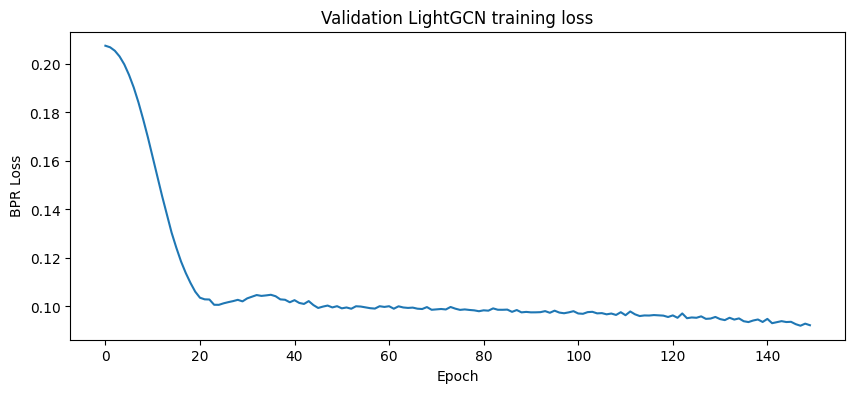

Validation graph users: 1676
Validation graph stocks: 865


In [13]:
validation_graph_edges = build_graph_interactions(VALID_START)
validation_graph = train_lightgcn(validation_graph_edges, epochs=GRAPH_EPOCHS)

plt.figure(figsize=(10, 4))
plt.plot(validation_graph["losses"])
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("Validation LightGCN training loss")
plt.show()

print("Validation graph users:", validation_graph["n_users"])
print("Validation graph stocks:", validation_graph["n_items"])

## 13. Customer history/style helpers + candidate market state strictly before research date

In [14]:
buy_by_customer = {
    u: g.sort_values("trade_date").reset_index(drop=True)
    for u, g in buy_events_mkt.groupby("customer_id")
}


def customer_history_profile(customer_id, t):
    t = pd.Timestamp(t)
    hist = buy_by_customer.get(customer_id)
    if hist is None:
        return None
    hist = hist[hist["trade_date"] < t].copy()
    if hist.empty:
        return None

    total_value = hist["transaction_value"].sum()
    total_count = len(hist)
    last_trade = hist["trade_date"].max()

    age_days = (t - hist["trade_date"]).dt.days.clip(lower=0)
    decay = np.exp(-np.log(2) * age_days / RECENCY_HALF_LIFE_DAYS)
    style_w = hist["transaction_value"].to_numpy(dtype=float) * decay.to_numpy(dtype=float)

    out = {
        "buy_orders": int(total_count),
        "total_buy_value": float(total_value),
        "unique_bought_stocks": int(hist["stock_code"].nunique()),
        "days_since_last_buy": int((t - last_trade).days),
    }

    for f, out_name in STYLE_FEATURES.items():
        out[out_name] = safe_weighted_mean(hist[f], style_w)

    if "icb_name" in hist.columns:
        sec = hist.dropna(subset=["icb_name"]).groupby("icb_name")["transaction_value"].sum()
        sec = sec / sec.sum() if sec.sum() > 0 else sec
        out["sector_pref"] = sec.to_dict()
    else:
        out["sector_pref"] = {}

    sg = hist.groupby("stock_code").agg(
        buy_value=("transaction_value", "sum"),
        buy_count=("transaction_value", "size"),
        last_buy=("trade_date", "max"),
    )
    sg["value_share"] = sg["buy_value"] / sg["buy_value"].sum()
    sg["frequency_share"] = sg["buy_count"] / sg["buy_count"].sum()
    sg["days_since_last_buy"] = (t - sg["last_buy"]).dt.days
    sg["recency"] = sg["days_since_last_buy"].map(recency_score)
    sg["preference_score"] = (
        0.4 * sg["value_share"] +
        0.3 * sg["frequency_share"] +
        0.3 * sg["recency"]
    )
    out["stock_pref"] = sg["preference_score"].to_dict()
    return out


# Candidate -> most recent market state strictly BEFORE research_date.
_candidate_enriched = candidate.merge(
    securities[[c for c in ["stock_code", "exchange", "icb_name"] if c in securities.columns]],
    on="stock_code",
    how="left",
)

_left_c = _candidate_enriched.sort_values(["research_date", "stock_code"]).copy()
_right_c = (
    market_features[["date", "stock_code"] + ASOF_FEATURES]
    .rename(columns={"date": "feature_date"})
    .sort_values(["feature_date", "stock_code"])
)
_left_c["stock_code"] = _left_c["stock_code"].astype(str)
_right_c["stock_code"] = _right_c["stock_code"].astype(str)

candidate_market_prior_all = pd.merge_asof(
    _left_c,
    _right_c,
    left_on="research_date",
    right_on="feature_date",
    by="stock_code",
    direction="backward",
    allow_exact_matches=False,
).sort_values(["research_date", "candidate_rank"]).reset_index(drop=True)


@lru_cache(maxsize=5000)
def _candidate_with_prior_market_cached(t_string, candidate_recs_tuple):
    t = pd.Timestamp(t_string)
    cand = candidate_market_prior_all[
        (candidate_market_prior_all["research_date"] == t) &
        (candidate_market_prior_all["recommendation"].isin(candidate_recs_tuple))
    ].copy()
    if cand.empty:
        return cand
    cand["market_score_norm"] = minmax01(cand["market_score"]).fillna(0.0)
    return cand.sort_values("candidate_rank").reset_index(drop=True)


def candidate_with_prior_market(t, candidate_recs=CANDIDATE_RECOMMENDATIONS):
    return _candidate_with_prior_market_cached(
        str(pd.Timestamp(t).date()), tuple(candidate_recs)
    ).copy()

## 14. GraphScore + StyleScore + HistoricalPreference

In [15]:
def graph_scores_for_candidates(customer_id, candidate_codes, graph):
    candidate_codes = list(candidate_codes)
    out = np.zeros(len(candidate_codes), dtype=float)

    user_map = graph["user_to_idx"]
    item_map = graph["item_to_idx"]

    if customer_id not in user_map:
        return pd.Series(out, index=candidate_codes, dtype=float)

    valid_pos = [j for j, c in enumerate(candidate_codes) if c in item_map]
    if not valid_pos:
        return pd.Series(out, index=candidate_codes, dtype=float)

    u = graph["user_embedding"][user_map[customer_id]]
    item_idx = [item_map[candidate_codes[j]] for j in valid_pos]
    V = graph["item_embedding"][item_idx]

    raw = V @ u
    raw_norm = minmax01(pd.Series(raw)).to_numpy(dtype=float)
    out[np.asarray(valid_pos, dtype=int)] = raw_norm
    return pd.Series(out, index=candidate_codes, dtype=float)


def score_customer_candidates(
    customer_id,
    t,
    graph,
    alpha=0.4,
    candidate_recs=CANDIDATE_RECOMMENDATIONS,
):
    t = pd.Timestamp(t)
    cand = candidate_with_prior_market(t, candidate_recs).copy()
    if cand.empty:
        return cand

    hist = customer_history_profile(customer_id, t)

    cand["historical_preference"] = 0.0
    cand["sector_match"] = 0.0
    cand["volatility_match"] = 0.0
    cand["momentum_match"] = 0.0
    cand["liquidity_match"] = 0.0
    cand["excess_return_match"] = 0.0
    cand["price_trend_match"] = 0.0

    if hist is not None:
        pref_map = hist.get("stock_pref", {})
        cand["historical_preference"] = cand["stock_code"].map(pref_map).fillna(0.0)
        cand["historical_preference"] = minmax01(cand["historical_preference"]).fillna(0.0)

        secpref = hist.get("sector_pref", {})
        if "icb_name" in cand.columns:
            cand["sector_match"] = cand["icb_name"].map(secpref).fillna(0.0)

        pref_pairs = [
            ("volatility_20d", "preferred_volatility", "volatility_match"),
            ("return_20d", "preferred_momentum", "momentum_match"),
            ("log_trading_value_est", "preferred_liquidity", "liquidity_match"),
            ("excess_return_20d", "preferred_excess_return", "excess_return_match"),
            ("price_vs_ma20", "preferred_price_vs_ma20", "price_trend_match"),
        ]

        for feature, pref_name, out_col in pref_pairs:
            pref = hist.get(pref_name, np.nan)
            scale = STYLE_SCALE.get(feature, 1.0)
            x = cand[feature].to_numpy(dtype=float)
            if np.isfinite(pref) and np.isfinite(scale) and scale > 0:
                vals = np.exp(-np.abs(x - pref) / scale)
                vals[~np.isfinite(vals)] = 0.0
                cand[out_col] = vals

    cand["graph_score"] = graph_scores_for_candidates(
        customer_id,
        cand["stock_code"].tolist(),
        graph,
    ).to_numpy()

    style_cols = [
        "sector_match", "volatility_match", "momentum_match",
        "liquidity_match", "excess_return_match", "price_trend_match"
    ]
    cand["suitability_score"] = cand[style_cols].mean(axis=1)

    cand["personalization_score"] = (
        GRAPH_COMPONENT_WEIGHT * cand["graph_score"] +
        STYLE_COMPONENT_WEIGHT * cand["suitability_score"] +
        HISTORY_COMPONENT_WEIGHT * cand["historical_preference"]
    )

    buy_count = hist.get("buy_orders", 0) if hist is not None else 0
    in_graph = customer_id in graph["user_to_idx"]
    cold_start = (buy_count < MIN_BUYS_FOR_PERSONALIZATION) and (not in_graph)

    effective_alpha = 1.0 if cold_start else float(alpha)
    cand["effective_alpha"] = effective_alpha
    cand["cold_start"] = cold_start
    cand["history_buy_orders"] = buy_count

    cand["final_score"] = (
        effective_alpha * cand["market_score_norm"] +
        (1 - effective_alpha) * cand["personalization_score"]
    )

    return cand.sort_values("final_score", ascending=False).reset_index(drop=True)

## 15. Sanity check one customer/date

In [16]:
example_dates = candidate[
    (candidate.research_date >= VALID_START) &
    (candidate.research_date <= VALID_END)
].research_date.unique()

example_date = pd.Timestamp(sorted(example_dates)[0])
example_customer = profile.sort_values("customer_id").customer_id.iloc[0]

example_scored = score_customer_candidates(
    example_customer,
    example_date,
    validation_graph,
    alpha=0.4,
)

cols = [
    "stock_code", "market_score", "market_score_norm", "graph_score",
    "historical_preference", "suitability_score", "personalization_score",
    "final_score", "candidate_rank"
]
display(example_scored[cols].head(10))

,stock_code,market_score,market_score_norm,graph_score,historical_preference,suitability_score,personalization_score,final_score,candidate_rank
0,DIG,87.46,0.883876,0.991868,0.0,0.391437,0.613365,0.721570,3
1,LDG,88.85,1.000000,0.852843,0.0,0.320800,0.522662,0.713597,1
2,CEO,87.66,0.900585,0.917610,0.0,0.244712,0.532219,0.679565,2
3,FRT,87.43,0.881370,0.752489,0.0,0.291433,0.463675,0.630753,4
4,HAG,84.46,0.633250,0.885488,0.0,0.377617,0.556029,0.586917,7
5,PTL,85.51,0.720969,0.594471,0.0,0.526483,0.455180,0.561496,6
6,SAM,80.51,0.303258,0.694435,1.0,0.517240,0.702390,0.542737,17
7,LCM,87.30,0.870510,0.429410,0.0,0.288998,0.301405,0.529047,5
8,ITA,80.19,0.276525,1.000000,0.0,0.609230,0.682769,0.520271,19
9,CII,83.21,0.528822,0.832375,0.0,0.277835,0.499538,0.511252,10


## 16. Future BUY ground truth + Candidate Coverage

In [17]:
# Dùng VNINDEX làm trading calendar chung.
calendar = sorted(
    pd.to_datetime(
        market_index[market_index.index_code == "VNINDEX"].date.unique()
    )
)
calendar = [pd.Timestamp(x) for x in calendar]
calendar_np = np.array(calendar, dtype="datetime64[ns]")

buy_tx = transactions[transactions["side"] == "BUY"].copy()
buys_by_date = {pd.Timestamp(d): g for d, g in buy_tx.groupby("trade_date")}


def future_dates(t, horizon=HORIZON_TRADING_DAYS):
    t = pd.Timestamp(t)
    pos = np.searchsorted(calendar_np, np.datetime64(t), side="right")
    return calendar[pos:pos + horizon]


def future_buys_map(t, horizon=HORIZON_TRADING_DAYS):
    dfs = [buys_by_date[d] for d in future_dates(t, horizon) if d in buys_by_date]
    if not dfs:
        return {}
    x = pd.concat(dfs, ignore_index=True)
    return x.groupby("customer_id")["stock_code"].apply(lambda s: set(s)).to_dict()


def candidate_coverage_for_date(t, candidate_recs=CANDIDATE_RECOMMENDATIONS):
    cand_set = set(
        candidate[
            (candidate.research_date == pd.Timestamp(t)) &
            candidate.recommendation.isin(candidate_recs)
        ].stock_code
    )
    f = future_buys_map(t)
    total = 0
    eligible = 0
    for stocks in f.values():
        total += len(stocks)
        eligible += len(stocks & cand_set)
    return eligible / total if total else np.nan

## 17. Evaluate one date

In [18]:
def evaluate_date(
    t,
    graph,
    alpha=0.4,
    k=TOP_K,
    candidate_recs=CANDIDATE_RECOMMENDATIONS,
    include_only_eligible=True,
):
    t = pd.Timestamp(t)
    cand = candidate[
        (candidate.research_date == t) &
        candidate.recommendation.isin(candidate_recs)
    ]
    cand_set = set(cand.stock_code)
    if not cand_set:
        return pd.DataFrame(), np.nan

    f = future_buys_map(t)
    rows = []

    for customer_id, future_stocks in f.items():
        relevant = future_stocks & cand_set
        if include_only_eligible and not relevant:
            continue

        scored = score_customer_candidates(
            customer_id,
            t,
            graph,
            alpha=alpha,
            candidate_recs=candidate_recs,
        )
        if scored.empty:
            continue

        variants = {
            "market": scored.sort_values("market_score_norm", ascending=False).stock_code.tolist(),
            "historical_pref": scored.sort_values("historical_preference", ascending=False).stock_code.tolist(),
            "graph": scored.sort_values("graph_score", ascending=False).stock_code.tolist(),
            "style": scored.sort_values("suitability_score", ascending=False).stock_code.tolist(),
            "graph_personalization": scored.sort_values("personalization_score", ascending=False).stock_code.tolist(),
            "graph_hybrid": scored.sort_values("final_score", ascending=False).stock_code.tolist(),
        }

        for model, recs in variants.items():
            m = ranking_metrics(recs, relevant, k)
            rows.append({
                "research_date": t,
                "customer_id": customer_id,
                "model": model,
                "eligible_relevant_count": len(relevant),
                **m,
            })

    return pd.DataFrame(rows), candidate_coverage_for_date(t, candidate_recs)

## 18. Validation — tune alpha for Graph Hybrid

In [19]:
valid_dates = sorted(
    candidate[
        (candidate.research_date >= VALID_START) &
        (candidate.research_date <= VALID_END)
    ].research_date.unique()
)
valid_dates = [pd.Timestamp(x) for x in valid_dates][::EVAL_DATE_STRIDE]
if MAX_VALID_DATES is not None:
    valid_dates = valid_dates[:MAX_VALID_DATES]

alpha_metric_rows = {float(a): [] for a in ALPHA_GRID}

for di, d in enumerate(valid_dates, start=1):
    if di == 1 or di % 10 == 0 or di == len(valid_dates):
        print(f"Validation {di}/{len(valid_dates)}: {d.date()}")

    cand_set = set(
        candidate[
            (candidate.research_date == d) &
            candidate.recommendation.isin(CANDIDATE_RECOMMENDATIONS)
        ].stock_code
    )
    future_map = future_buys_map(d)

    for customer_id, future_stocks in future_map.items():
        relevant = future_stocks & cand_set
        if not relevant:
            continue

        scored = score_customer_candidates(
            customer_id,
            d,
            validation_graph,
            alpha=0.4,
        )
        if scored.empty:
            continue

        cold = bool(scored["cold_start"].iloc[0])

        for alpha in ALPHA_GRID:
            if cold:
                tmp_score = scored["market_score_norm"].to_numpy()
            else:
                tmp_score = (
                    alpha * scored["market_score_norm"].to_numpy() +
                    (1 - alpha) * scored["personalization_score"].to_numpy()
                )
            order = np.argsort(-tmp_score)
            recs = scored.iloc[order].stock_code.tolist()
            alpha_metric_rows[float(alpha)].append(
                ranking_metrics(recs, relevant, TOP_K)
            )
    gc.collect()

alpha_rows = []
for alpha, rows in alpha_metric_rows.items():
    if not rows:
        continue
    z = pd.DataFrame(rows)
    alpha_rows.append({
        "alpha": alpha,
        f"ndcg@{TOP_K}": z[f"ndcg@{TOP_K}"].mean(),
        f"recall@{TOP_K}": z[f"recall@{TOP_K}"].mean(),
        f"precision@{TOP_K}": z[f"precision@{TOP_K}"].mean(),
        f"hitrate@{TOP_K}": z[f"hitrate@{TOP_K}"].mean(),
        f"map@{TOP_K}": z[f"map@{TOP_K}"].mean(),
        "n_pairs": len(z),
    })

alpha_results = pd.DataFrame(alpha_rows).sort_values(f"ndcg@{TOP_K}", ascending=False)
display(alpha_results)

BEST_ALPHA = float(alpha_results.iloc[0].alpha) if len(alpha_results) else 0.4
print("BEST_ALPHA =", BEST_ALPHA)
alpha_results.to_csv(EVAL_DIR / "graph_validation_alpha_tuning.csv", index=False)

Validation 1/120: 2022-01-04
Validation 10/120: 2022-01-17
Validation 20/120: 2022-02-07
Validation 30/120: 2022-02-21
Validation 40/120: 2022-03-07
Validation 50/120: 2022-03-21
Validation 60/120: 2022-04-04
Validation 70/120: 2022-04-19
Validation 80/120: 2022-05-05
Validation 90/120: 2022-05-19
Validation 100/120: 2022-06-02
Validation 110/120: 2022-06-16
Validation 120/120: 2022-06-30


,alpha,ndcg@5,recall@5,precision@5,hitrate@5,map@5,n_pairs
6,0.6,0.223539,0.346422,0.077990,0.376010,0.177370,38100
5,0.5,0.223050,0.346124,0.077963,0.375433,0.176796,38100
7,0.7,0.220656,0.340238,0.076656,0.369685,0.175471,38100
4,0.4,0.219161,0.339066,0.076268,0.367848,0.174033,38100
8,0.8,0.219025,0.338650,0.076215,0.367979,0.173903,38100
3,0.3,0.216782,0.332749,0.074740,0.361286,0.172936,38100
9,0.9,0.215391,0.334269,0.075276,0.363412,0.170600,38100
10,1.0,0.213505,0.333852,0.075192,0.363123,0.168299,38100
2,0.2,0.208542,0.315232,0.070787,0.343255,0.167910,38100
1,0.1,0.191344,0.286369,0.064058,0.312257,0.154962,38100


BEST_ALPHA = 0.6


## 19. Train TEST graph — only history before 2022-07-01

TEST graph edges: 102991
Epoch 001/150 | BPR Loss = 0.201561
Epoch 025/150 | BPR Loss = 0.097467
Epoch 050/150 | BPR Loss = 0.096363
Epoch 075/150 | BPR Loss = 0.095190
Epoch 100/150 | BPR Loss = 0.095091
Epoch 125/150 | BPR Loss = 0.094010
Epoch 150/150 | BPR Loss = 0.091870


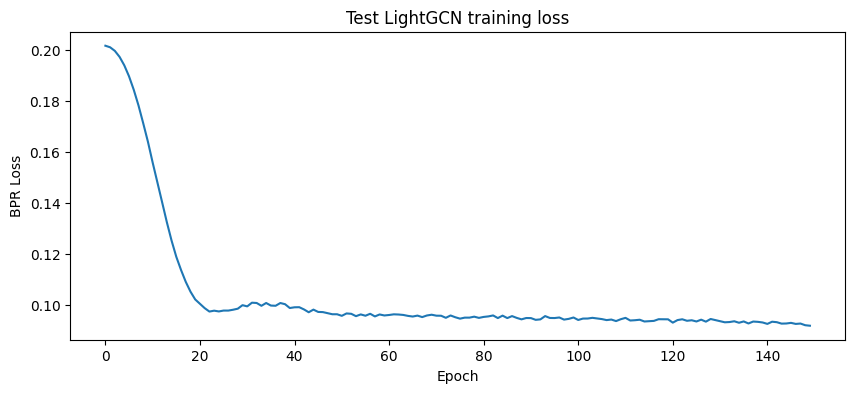

In [20]:
test_graph_edges = build_graph_interactions(TEST_START)
print("TEST graph edges:", len(test_graph_edges))

test_graph = train_lightgcn(test_graph_edges, epochs=GRAPH_EPOCHS)

plt.figure(figsize=(10, 4))
plt.plot(test_graph["losses"])
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("Test LightGCN training loss")
plt.show()

## 20. Full temporal TEST — baselines vs Graph Hybrid

In [21]:
test_dates = sorted(
    candidate[
        (candidate.research_date >= TEST_START) &
        (candidate.research_date <= TEST_END)
    ].research_date.unique()
)
test_dates = [pd.Timestamp(x) for x in test_dates][::EVAL_DATE_STRIDE]
if MAX_TEST_DATES is not None:
    test_dates = test_dates[:MAX_TEST_DATES]

frames = []
coverage_rows = []

for i, d in enumerate(test_dates, start=1):
    if i == 1 or i % 10 == 0 or i == len(test_dates):
        print(f"Test {i}/{len(test_dates)}: {d.date()}")

    ev, cov = evaluate_date(
        d,
        graph=test_graph,
        alpha=BEST_ALPHA,
        k=TOP_K,
    )
    if not ev.empty:
        frames.append(ev)
    coverage_rows.append({"research_date": d, "candidate_coverage": cov})
    gc.collect()


test_eval = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
coverage_df = pd.DataFrame(coverage_rows)

metric_cols = [
    f"precision@{TOP_K}", f"recall@{TOP_K}", f"hitrate@{TOP_K}",
    f"ndcg@{TOP_K}", f"map@{TOP_K}"
]

summary = (
    test_eval.groupby("model")[metric_cols].mean()
    .sort_values(f"ndcg@{TOP_K}", ascending=False)
    if not test_eval.empty else pd.DataFrame()
)

display(summary)
print("Mean candidate coverage:", coverage_df.candidate_coverage.mean())

safe_save_table(test_eval, EVAL_DIR / "graph_test_pair_metrics")
summary.to_csv(EVAL_DIR / "graph_test_model_summary.csv")
coverage_df.to_csv(EVAL_DIR / "candidate_coverage_daily.csv", index=False)

Test 1/129: 2022-07-01
Test 10/129: 2022-07-14
Test 20/129: 2022-07-28
Test 30/129: 2022-08-11
Test 40/129: 2022-08-25
Test 50/129: 2022-09-12
Test 60/129: 2022-09-26
Test 70/129: 2022-10-10
Test 80/129: 2022-10-24
Test 90/129: 2022-11-07
Test 100/129: 2022-11-21
Test 110/129: 2022-12-05
Test 120/129: 2022-12-19
Test 129/129: 2022-12-30


,precision@5,recall@5,hitrate@5,ndcg@5,map@5
model,,,,,
graph_hybrid,0.078928,0.349364,0.380360,0.226407,0.179824
market,0.079006,0.349558,0.380165,0.226244,0.179626
historical_pref,0.069777,0.310658,0.338195,0.209455,0.170699
graph_personalization,0.054835,0.242693,0.267295,0.167520,0.137888
graph,0.047730,0.211364,0.233053,0.141585,0.114391
style,0.040215,0.176704,0.196939,0.111655,0.086783


Mean candidate coverage: 0.29676664934781605


## 21. Plot model comparison

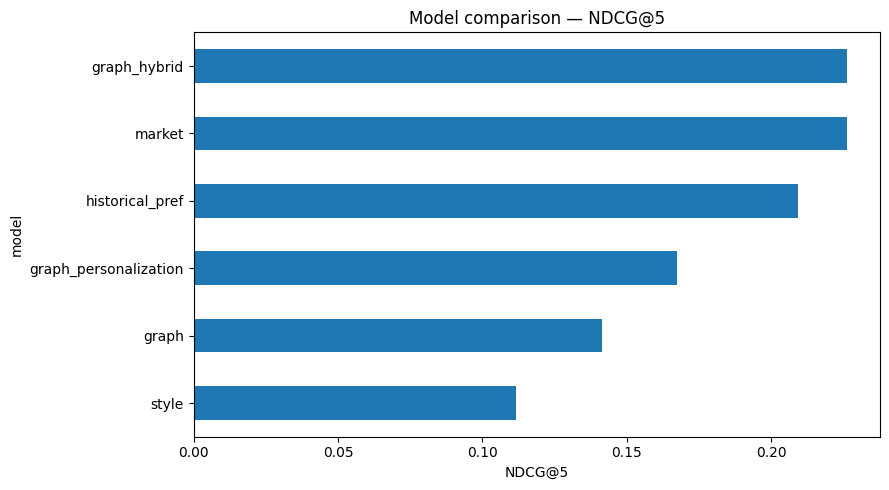

In [22]:
if not summary.empty:
    ax = summary[f"ndcg@{TOP_K}"].sort_values().plot(
        kind="barh", figsize=(9, 5), title=f"Model comparison — NDCG@{TOP_K}"
    )
    ax.set_xlabel(f"NDCG@{TOP_K}")
    plt.tight_layout()
    plt.show()

## 22. Explainability

In [23]:
def explain_row(row):
    reasons = []
    if row.get("graph_score", 0) >= 0.70:
        reasons.append("graph cho thấy tương tác mạnh với hành vi khách hàng")
    if row.get("sector_match", 0) >= 0.20:
        reasons.append("ngành phù hợp lịch sử giao dịch")
    if row.get("volatility_match", 0) >= 0.70:
        reasons.append("mức biến động gần phong cách khách hàng")
    if row.get("liquidity_match", 0) >= 0.70:
        reasons.append("thanh khoản gần phong cách khách hàng")
    if row.get("momentum_match", 0) >= 0.70:
        reasons.append("momentum gần các mã khách thường mua")
    if row.get("historical_preference", 0) >= 0.50:
        reasons.append("có preference lịch sử cao")
    if not reasons:
        reasons.append("được xếp hạng chủ yếu bởi MarketScore/candidate research")
    return "; ".join(reasons[:3])

## 23. Train final graph and export Top-K recommendations

In [24]:
FINAL_DATE = candidate.loc[candidate["research_date"] <= TEST_END, "research_date"].max()
print("FINAL_DATE:", FINAL_DATE.date())

final_graph_edges = build_graph_interactions(FINAL_DATE)
final_graph = train_lightgcn(final_graph_edges, epochs=GRAPH_EPOCHS)

# Customer universe: chỉ customer đã mở tài khoản trước final date.
customer_ids = profile.loc[
    profile["account_open_date"] < FINAL_DATE,
    "customer_id"
].dropna().astype(str).tolist()

rows = []
for i, customer_id in enumerate(customer_ids, start=1):
    scored = score_customer_candidates(
        customer_id,
        FINAL_DATE,
        final_graph,
        alpha=BEST_ALPHA,
    )
    if scored.empty:
        continue

    top = scored.head(TOP_K).copy()
    top["rank"] = np.arange(1, len(top) + 1)
    top["customer_id"] = customer_id
    top["research_date"] = FINAL_DATE
    top["reason"] = top.apply(explain_row, axis=1)
    rows.append(top)

    if i == 1 or i % 250 == 0 or i == len(customer_ids):
        print(f"Final recommendations: {i}/{len(customer_ids)} customers")

final_recs = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

FINAL_COLS = [
    "research_date", "customer_id", "stock_code", "rank",
    "market_score", "market_score_norm", "graph_score",
    "historical_preference", "suitability_score", "personalization_score",
    "final_score", "effective_alpha", "cold_start", "reason"
]
FINAL_COLS = [c for c in FINAL_COLS if c in final_recs.columns]

final_path = REC_DIR / f"graph_top{TOP_K}_recommendations_{FINAL_DATE.date()}.csv"
final_recs[FINAL_COLS].to_csv(final_path, index=False)

display(final_recs[FINAL_COLS].head(20))
print("Final recommendation rows:", len(final_recs))
print("Saved:", final_path)

FINAL_DATE: 2022-12-30
Epoch 001/150 | BPR Loss = 0.204165
Epoch 025/150 | BPR Loss = 0.095886
Epoch 050/150 | BPR Loss = 0.094696
Epoch 075/150 | BPR Loss = 0.092921
Epoch 100/150 | BPR Loss = 0.091833
Epoch 125/150 | BPR Loss = 0.091739
Epoch 150/150 | BPR Loss = 0.090390
Final recommendations: 1/2000 customers
Final recommendations: 250/2000 customers
Final recommendations: 500/2000 customers
Final recommendations: 750/2000 customers
Final recommendations: 1000/2000 customers
Final recommendations: 1250/2000 customers
Final recommendations: 1500/2000 customers
Final recommendations: 1750/2000 customers
Final recommendations: 2000/2000 customers


,research_date,customer_id,stock_code,rank,market_score,market_score_norm,graph_score,historical_preference,suitability_score,personalization_score,final_score,effective_alpha,cold_start,reason
0,2022-12-30,CUS000001,NAG,1,82.44,1.000000,0.462294,0.000000,0.316561,0.326115,0.730446,0.6,False,được xếp hạng chủ yếu bởi MarketScore/candidat...
1,2022-12-30,CUS000001,STB,2,77.87,0.724034,1.000000,0.000000,0.588562,0.676568,0.705048,0.6,False,graph cho thấy tương tác mạnh với hành vi khác...
2,2022-12-30,CUS000001,CTF,3,78.59,0.767512,0.667467,0.000000,0.552099,0.499363,0.660252,0.6,False,thanh khoản gần phong cách khách hàng; momentu...
3,2022-12-30,CUS000001,APG,4,76.26,0.626812,0.503848,1.000000,0.498886,0.601590,0.616723,0.6,False,mức biến động gần phong cách khách hàng; thanh...
4,2022-12-30,CUS000001,TCM,5,76.55,0.644324,0.658949,0.000000,0.604942,0.510957,0.590977,0.6,False,mức biến động gần phong cách khách hàng; thanh...
5,2022-12-30,CUS000002,NAG,1,82.44,1.000000,0.468440,1.000000,0.384610,0.549603,0.819841,0.6,False,mức biến động gần phong cách khách hàng; thanh...
6,2022-12-30,CUS000002,CTF,2,78.59,0.767512,0.671274,0.711885,0.657385,0.675230,0.730599,0.6,False,thanh khoản gần phong cách khách hàng; momentu...
7,2022-12-30,CUS000002,STB,3,77.87,0.724034,1.000000,0.097002,0.600446,0.699534,0.714234,0.6,False,graph cho thấy tương tác mạnh với hành vi khác...
8,2022-12-30,CUS000002,TCM,4,76.55,0.644324,0.663627,0.997098,0.625647,0.718927,0.674165,0.6,False,mức biến động gần phong cách khách hàng; thanh...
9,2022-12-30,CUS000002,LPB,5,75.74,0.595411,0.672711,0.092733,0.640370,0.547013,0.576051,0.6,False,mức biến động gần phong cách khách hàng; thanh...


Final recommendation rows: 10000
Saved: /kaggle/working/stock_recommender_graph/recommendations/graph_top5_recommendations_2022-12-30.csv


## 24. Save final graph embeddings and mappings

In [25]:
np.save(GRAPH_DIR / "customer_embeddings.npy", final_graph["user_embedding"])
np.save(GRAPH_DIR / "stock_embeddings.npy", final_graph["item_embedding"])

pd.DataFrame({
    "customer_id": final_graph["user_codes"],
    "user_idx": np.arange(final_graph["n_users"]),
}).to_csv(GRAPH_DIR / "graph_user_mapping.csv", index=False)

pd.DataFrame({
    "stock_code": final_graph["item_codes"],
    "item_idx": np.arange(final_graph["n_items"]),
}).to_csv(GRAPH_DIR / "graph_stock_mapping.csv", index=False)

pd.DataFrame({
    "epoch": np.arange(1, len(final_graph["losses"]) + 1),
    "bpr_loss": final_graph["losses"],
}).to_csv(GRAPH_DIR / "final_graph_training_loss.csv", index=False)

print("Saved graph artifacts ->", GRAPH_DIR)

Saved graph artifacts -> /kaggle/working/stock_recommender_graph/graph


## 25. Output summary

In [26]:
for title, directory in [
    ("CLEANED", CLEAN_DIR),
    ("FEATURES", FEATURE_DIR),
    ("GRAPH", GRAPH_DIR),
    ("EVALUATION", EVAL_DIR),
    ("RECOMMENDATIONS", REC_DIR),
]:
    print(f"\n=== {title} ===")
    for p in sorted(directory.glob("*")):
        print(p.name)


=== CLEANED ===
candidate_stocks_research_clean.parquet
customer_holdings_clean.parquet
customer_profile_clean.csv
customer_profile_static.csv
customer_transactions_clean.parquet
market_index_daily_clean.parquet
securities_master_clean.csv
stock_market_daily_clean.parquet

=== FEATURES ===
buy_events_with_prior_market.parquet
index_features_daily.parquet
market_features_daily.parquet

=== GRAPH ===
customer_embeddings.npy
final_graph_training_loss.csv
graph_stock_mapping.csv
graph_user_mapping.csv
stock_embeddings.npy

=== EVALUATION ===
candidate_coverage_daily.csv
graph_test_model_summary.csv
graph_test_pair_metrics.parquet
graph_validation_alpha_tuning.csv

=== RECOMMENDATIONS ===
graph_top5_recommendations_2022-12-30.csv
